In [7]:
import os
# force CPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from IPython.display import Image

def display_images(image_path1, image_path2):
        # read images
        img_A = mpimg.imread(image_path1)
        img_B = mpimg.imread(image_path2)

        # pad top with white space
        larger = max(img_A.shape[0], img_B.shape[0])
        img_A = np.pad(img_A, ((larger - img_A.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)
        img_B = np.pad(img_B, ((larger - img_B.shape[0], 0), (0, 0), (0, 0)), mode='constant', constant_values=1)

        # stack
        img = np.concatenate((img_A, img_B), axis=1)
        # save tmp image
        tmp_path = 'tmp.png'
        plt.imsave(tmp_path, img)
        return Image(tmp_path, width=600)

In [2]:
chrom = 'chr11'
start = 31000000
region = 'chr11:31373941-33024355'

In [12]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname baseline \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_CTCF_ATAC_14_1d_tracks_5kb_norm_10_wd.ckpt \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --min-val-pred 0.5 \
    --plot-bigwigs ctcf atac rad21 rnaseq cage \
    --plot-pred-bigwigs ctcf atac rad21 rnaseq cage \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

### WT Prediction

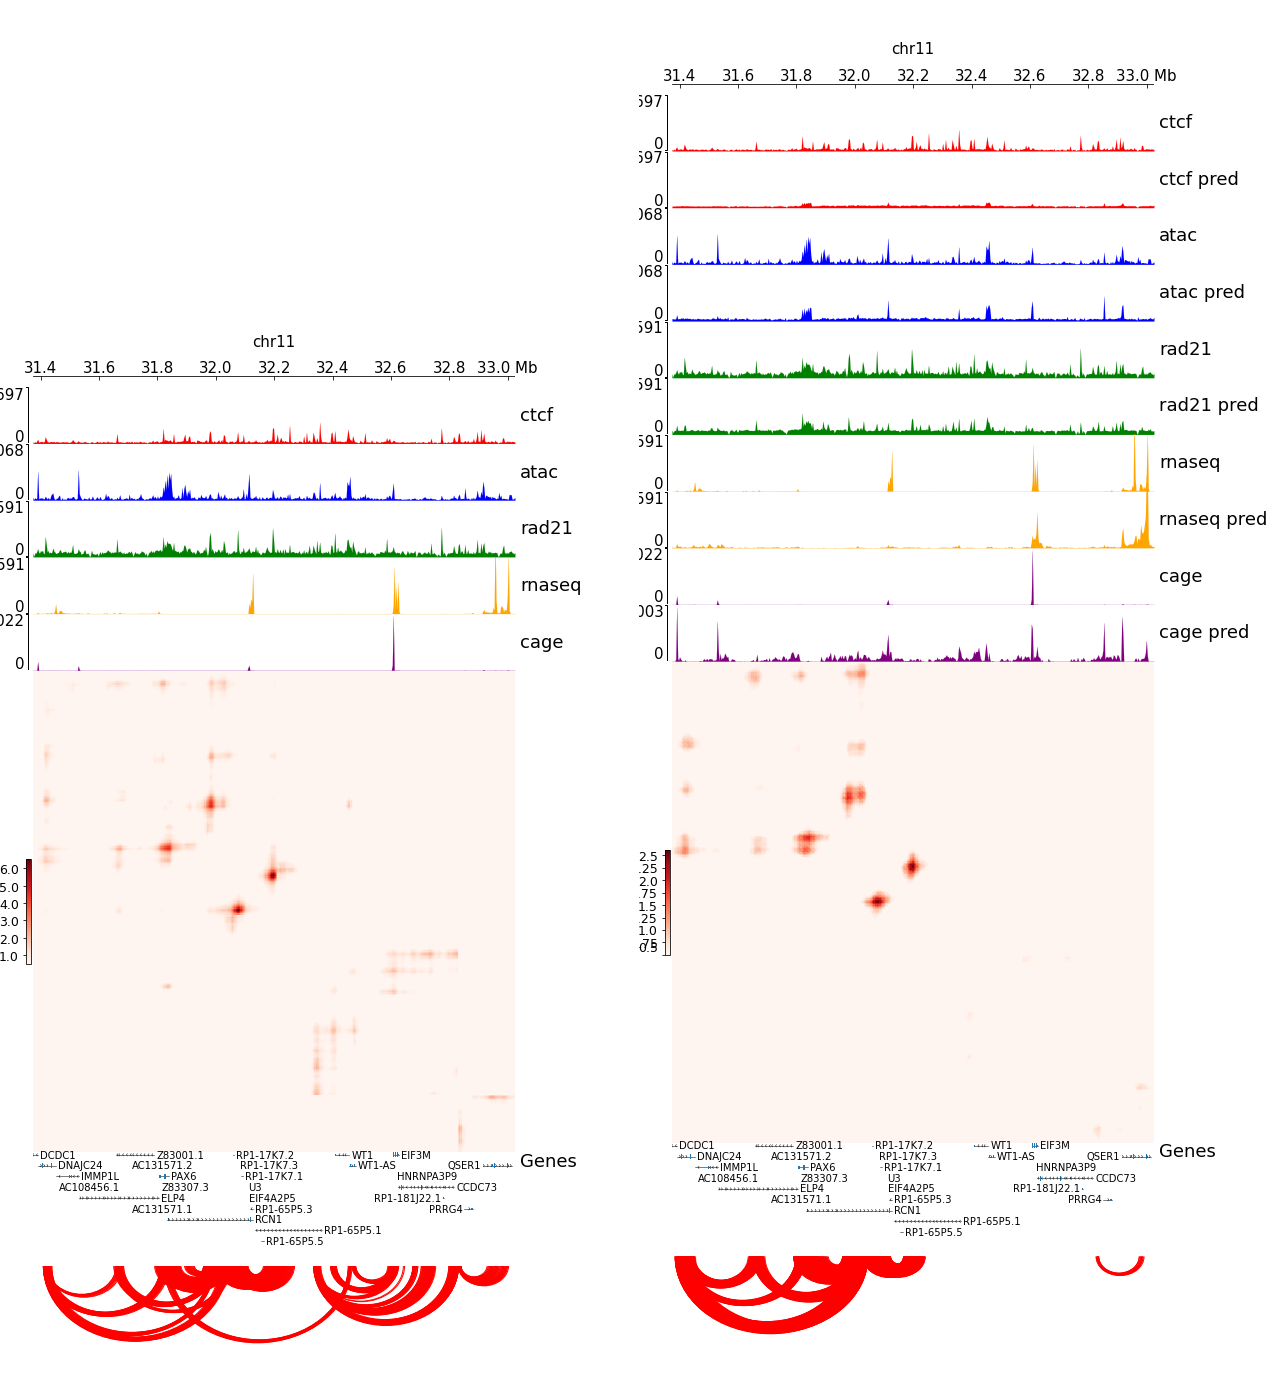

In [13]:
display_images(f'outputs/baseline_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_true_tracks.png', 
               f'outputs/baseline_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_pred_tracks.png')

In [14]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_only \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_CTCF_ATAC_14_1d_tracks_5kb_norm_10_wd.ckpt \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start \
    --ko-width 2097152 \
    --ko ctcf \
    --ko-mode knockout \
    --peak-height 1.0 \
    --min-val-pred 0.0 \
    --max-val-pred 2.5 \
    --plot-bigwigs ctcf atac rad21 rnaseq cage \
    --plot-pred-bigwigs ctcf atac rad21 rnaseq cage \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

### CTCTF KO Prediction

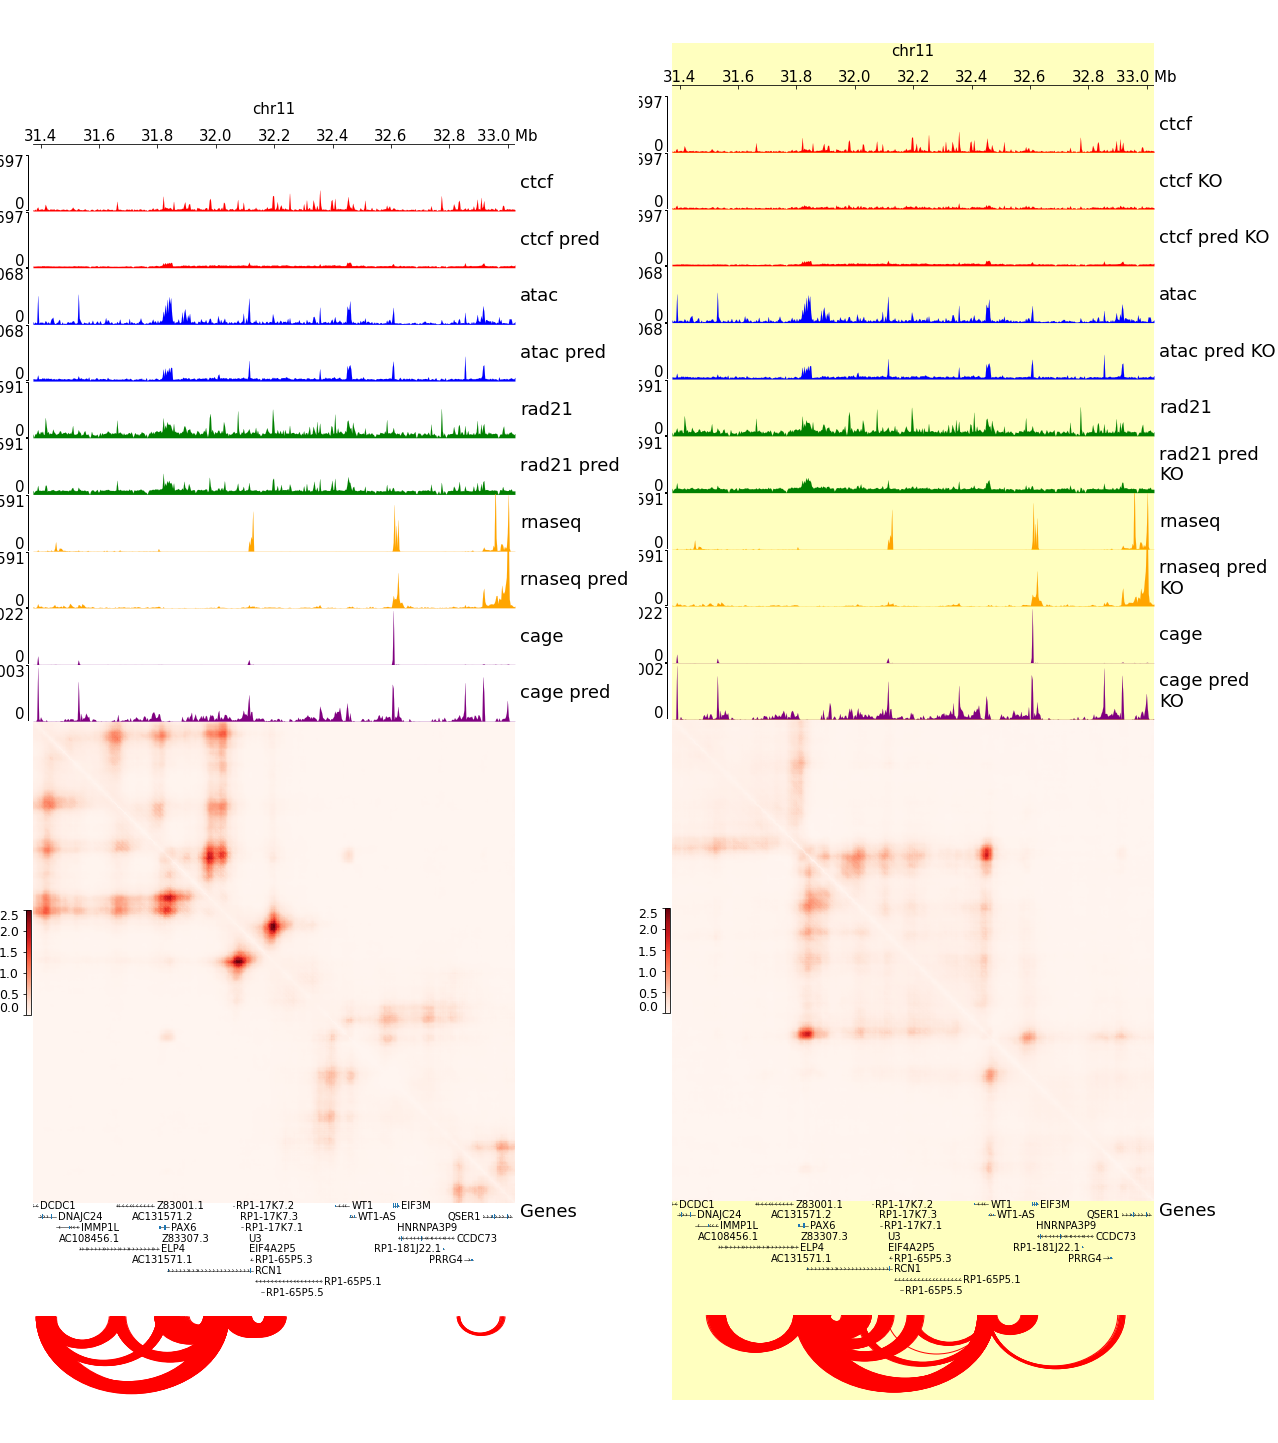

In [15]:
display_images(f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_pred_tracks.png', 
               f'outputs/ctcf_ko_only_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png')

In [16]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_atac_increase \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_CTCF_ATAC_14_1d_tracks_5kb_norm_10_wd.ckpt \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start 31810000 32430000 \
    --ko-width 2097152 50000 50000 \
    --ko ctcf atac atac \
    --ko-mode knockout increase_1.5 increase_1.5 \
    --peak-height 1.0 \
    --min-val-pred 0.0 \
    --max-val-pred 1.5 \
    --plot-bigwigs ctcf atac rad21 rnaseq cage \
    --plot-pred-bigwigs ctcf atac rad21 rnaseq cage \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

In [ ]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_atac_increase_2 \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_CTCF_ATAC_14_1d_tracks_5kb_norm_10_wd.ckpt \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start 31810000 32430000 \
    --ko-width 2097152 50000 50000 \
    --ko ctcf atac atac \
    --ko-mode knockout increase_2 increase_2 \
    --peak-height 1.0 \
    --min-val-pred 0.0 \
    --max-val-pred 1.5 \
    --plot-bigwigs ctcf atac rad21 rnaseq cage \
    --plot-pred-bigwigs ctcf atac rad21 rnaseq cage \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

### CTCF KO and ATAC peak increase by 1.5x and 2x

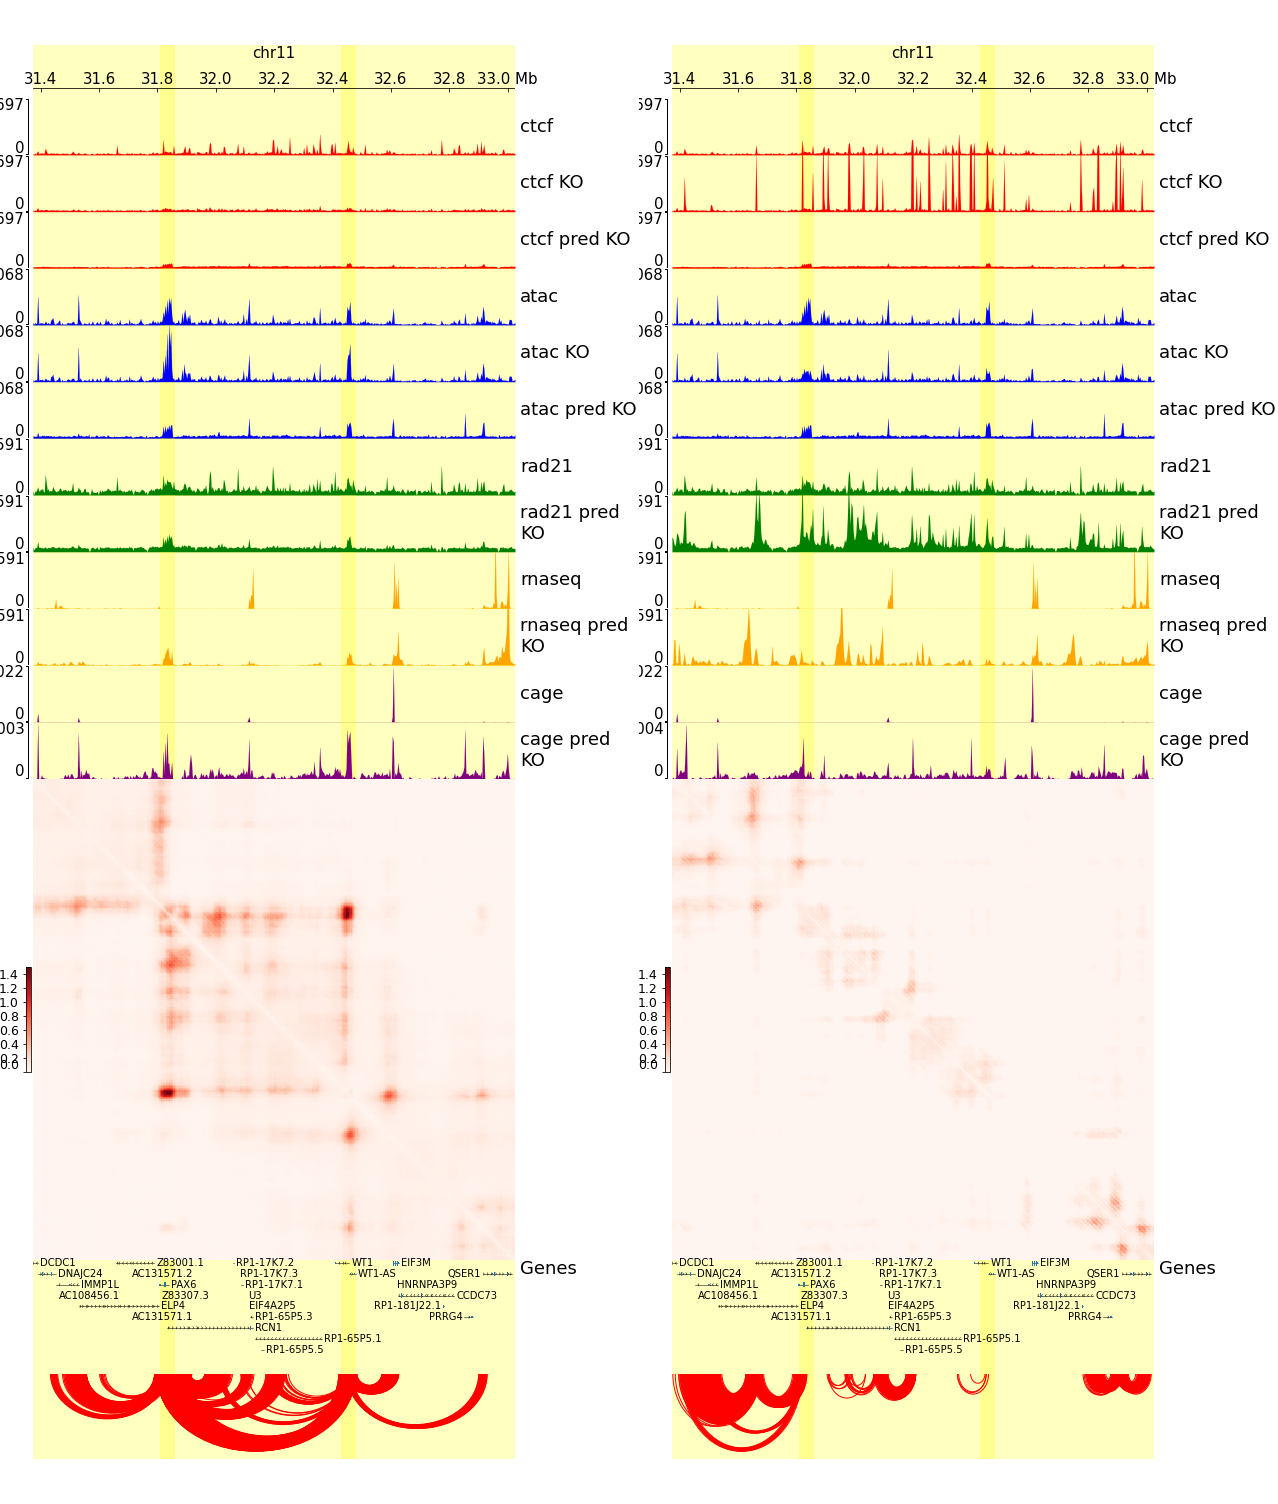

In [24]:
display_images(f'outputs/ctcf_ko_atac_increase_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png',
               f'outputs/ctcf_ko_atac_increase_2_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png')

In [23]:
! uv pip install ../.[training] --no-deps

Using Python 3.12.10 environment at: /home/dmp131/anaconda3/envs/cshark
Resolved 1 package in 3ms                                            
   Building cshark @ file:///home/dmp131/C.Shark                       
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
   Building cshark @ file:///home/dmp131/C.Shark               
      Built cshark

In [27]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_atac_cluster \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_CTCF_ATAC_14_1d_tracks_5kb_norm_10_wd.ckpt \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start 31810000 32430000 \
    --ko-width 2097152 50000 50000 \
    --ko ctcf atac atac \
    --ko-mode knockout cluster_0.05 cluster_0.05 \
    --peak-height 1.0 \
    --min-val-pred 0.0 \
    --max-val-pred 1.5 \
    --plot-bigwigs ctcf atac rad21 rnaseq cage \
    --plot-pred-bigwigs ctcf atac rad21 rnaseq cage \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

In [28]:
! python ../src/cshark/inference/perturb.py \
    --celltype hESC_WT_5kb_norm_10 \
    --outname ctcf_ko_atac_cluster_2 \
    --chr $chrom \
    --start $start \
    --model /mnt/jinstore/JinLab02/dmp131/C.Shark/checkpoints/deeploop_hESC_CTCF_ATAC_14_1d_tracks_5kb_norm_10_wd.ckpt \
    --seq ../cshark_data/data/hg19/dna_sequence \
    --matrix-size 512 \
    --resolution 4096 \
    --latent_size 256 \
    --seq-filter-size 15 \
    --no-recon \
    --region $region \
    --ko-start $start 31810000 32430000 \
    --ko-width 2097152 50000 50000 \
    --ko ctcf atac atac \
    --ko-mode knockout cluster_0.1 cluster_0.1 \
    --peak-height 1.0 \
    --min-val-pred 0.0 \
    --max-val-pred 1.5 \
    --plot-bigwigs ctcf atac rad21 rnaseq cage \
    --plot-pred-bigwigs ctcf atac rad21 rnaseq cage \
    --bigwigs ctcf=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/ctcf.bw \
              atac=../cshark_data/data/hg19/hESC_WT_5kb_norm_10/genomic_features/atac.bw \
    --silent

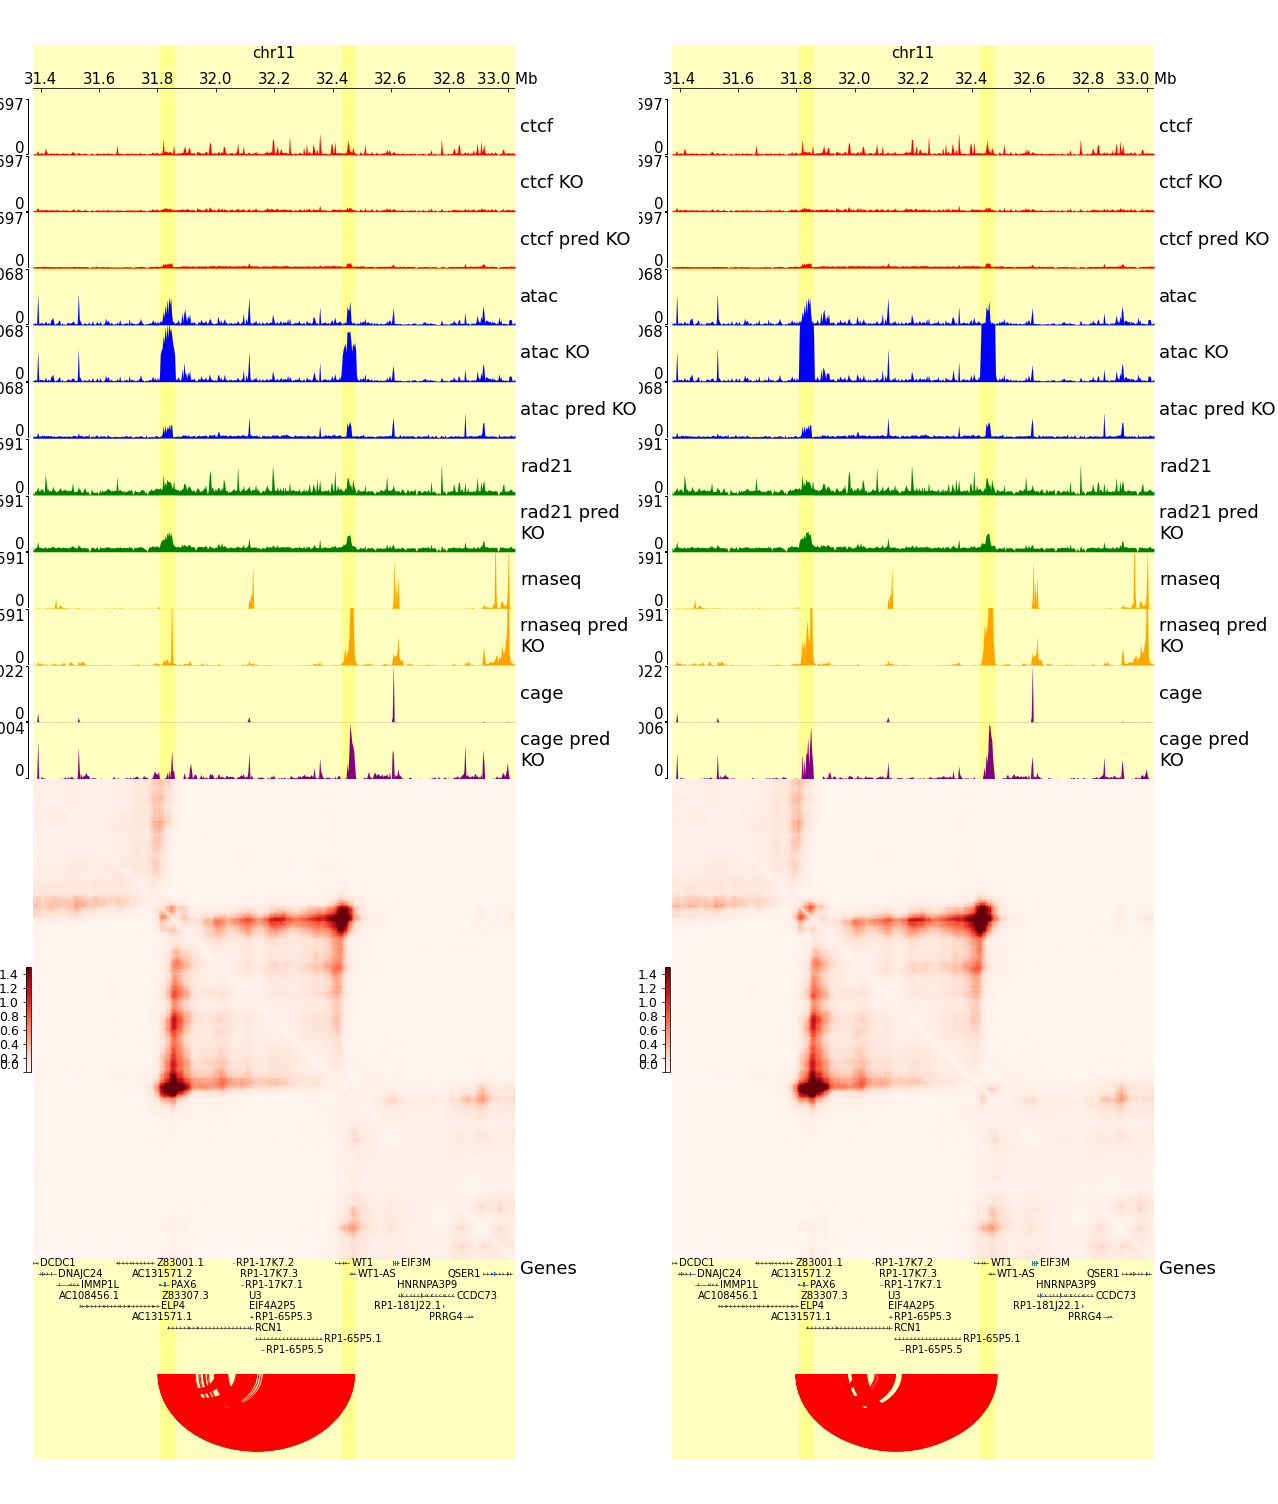

In [29]:
display_images(f'outputs/ctcf_ko_atac_cluster_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png',
               f'outputs/ctcf_ko_atac_cluster_2_hESC_WT_5kb_norm_10_{chrom}_{start}_ctcf_ko_tracks.png')